In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos
data = {
    "y_true": [1,1,1,1,1,1,1,1,1,1,
               0,0,0,0,0,0,0,0,0,0],
    "score":  [0.90,0.80,0.60,0.55,0.54,0.51,0.40,0.38,0.34,0.30,
               0.70,0.53,0.52,0.50,0.39,0.37,0.36,0.35,0.33,0.10]
}

df = pd.DataFrame(data)


Curva ROC Manual

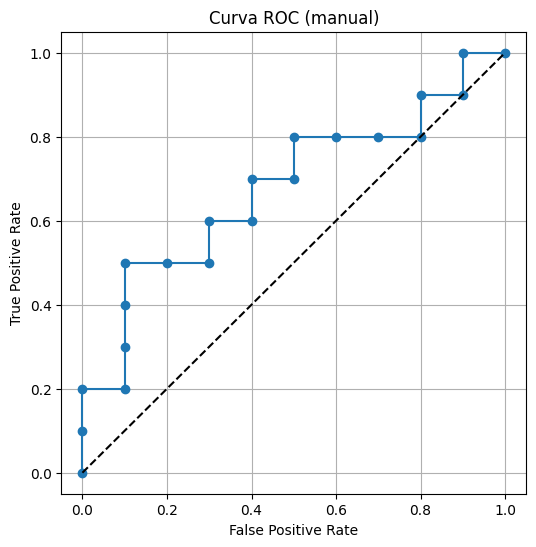

In [ ]:
df_sorted = df.sort_values("score", ascending=False)

P = sum(df_sorted["y_true"] == 1)
N = sum(df_sorted["y_true"] == 0)

TP = FP = 0
tpr_list = [0]
fpr_list = [0]

for _, row in df_sorted.iterrows():
    if row["y_true"] == 1:
        TP += 1
    else:
        FP += 1

    tpr_list.append(TP / P)
    fpr_list.append(FP / N)

plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, marker='o')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (manual)")
plt.grid(True)
plt.show()

Curva ROC automatico

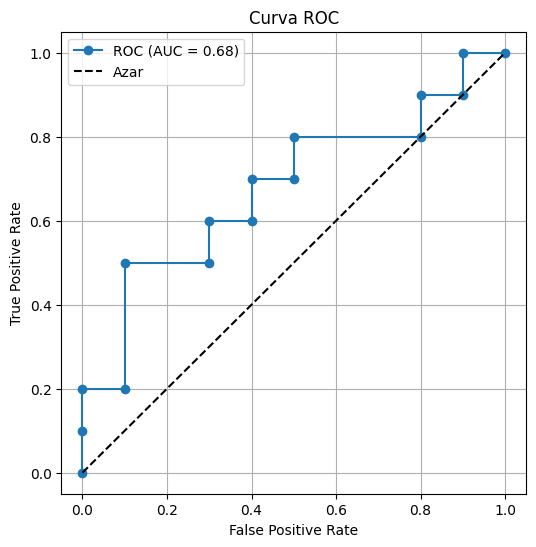

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(df["y_true"], df["score"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, marker='o', label=f"ROC (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
roc_points = pd.DataFrame({
    "threshold": thresholds,
    "TPR": tpr,
    "FPR": fpr
})

roc_points

,threshold,TPR,FPR
0,inf,0.0,0.0
1,0.90,0.1,0.0
2,0.80,0.2,0.0
3,0.70,0.2,0.1
4,0.54,0.5,0.1
5,0.52,0.5,0.3
6,0.51,0.6,0.3
7,0.50,0.6,0.4
8,0.40,0.7,0.4
9,0.39,0.7,0.5
